In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration for clearer plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the RAW dataset
# We use '../' to go up one level from 'notebooks/' to the project root
try:
    df = pd.read_csv('../data/raw/dataset.csv')
    bf = pd.read_csv('../data/processed/final.csv')
    print(f"Dataset Loaded Successfully. Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("Error: Could not find the file. Make sure 'dataset.csv' is in 'data/raw/'")

Dataset Loaded Successfully. Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Missing Values (%):
 Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


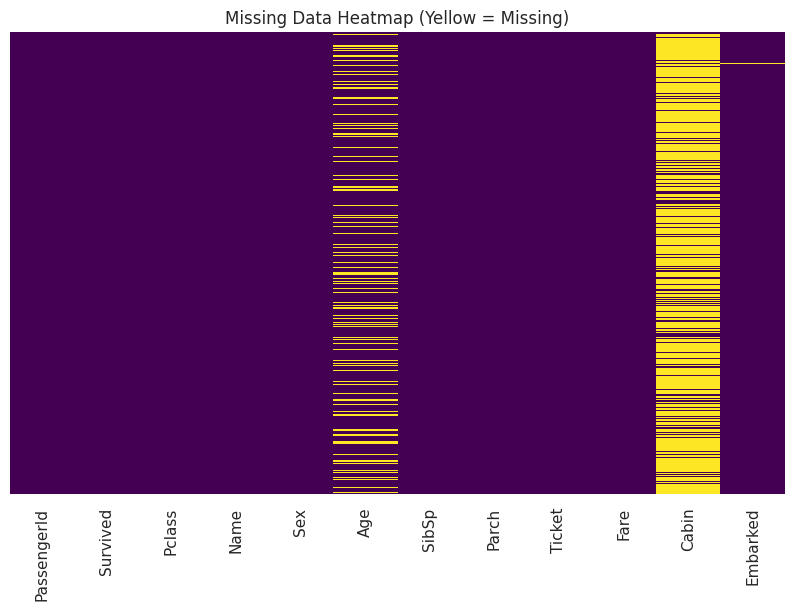

In [2]:
# 1. Calculate percentage of missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
print("Missing Values (%):\n", missing_percent[missing_percent > 0])

# 2. Visual Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap (Yellow = Missing)')
plt.show()

/tmp/ipykernel_6112/1655835321.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='pastel')


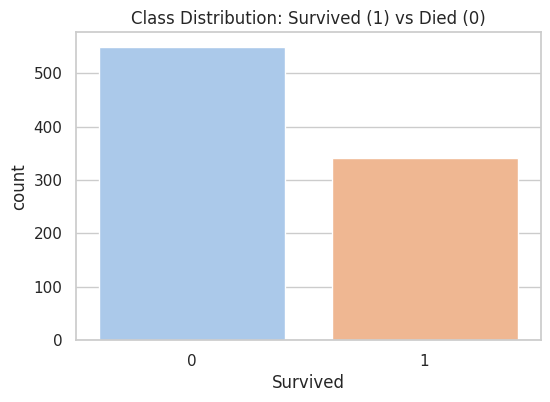

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [3]:
# Countplot for Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='pastel')
plt.title('Class Distribution: Survived (1) vs Died (0)')
plt.show()

# Exact numbers
print(df['Survived'].value_counts(normalize=True))

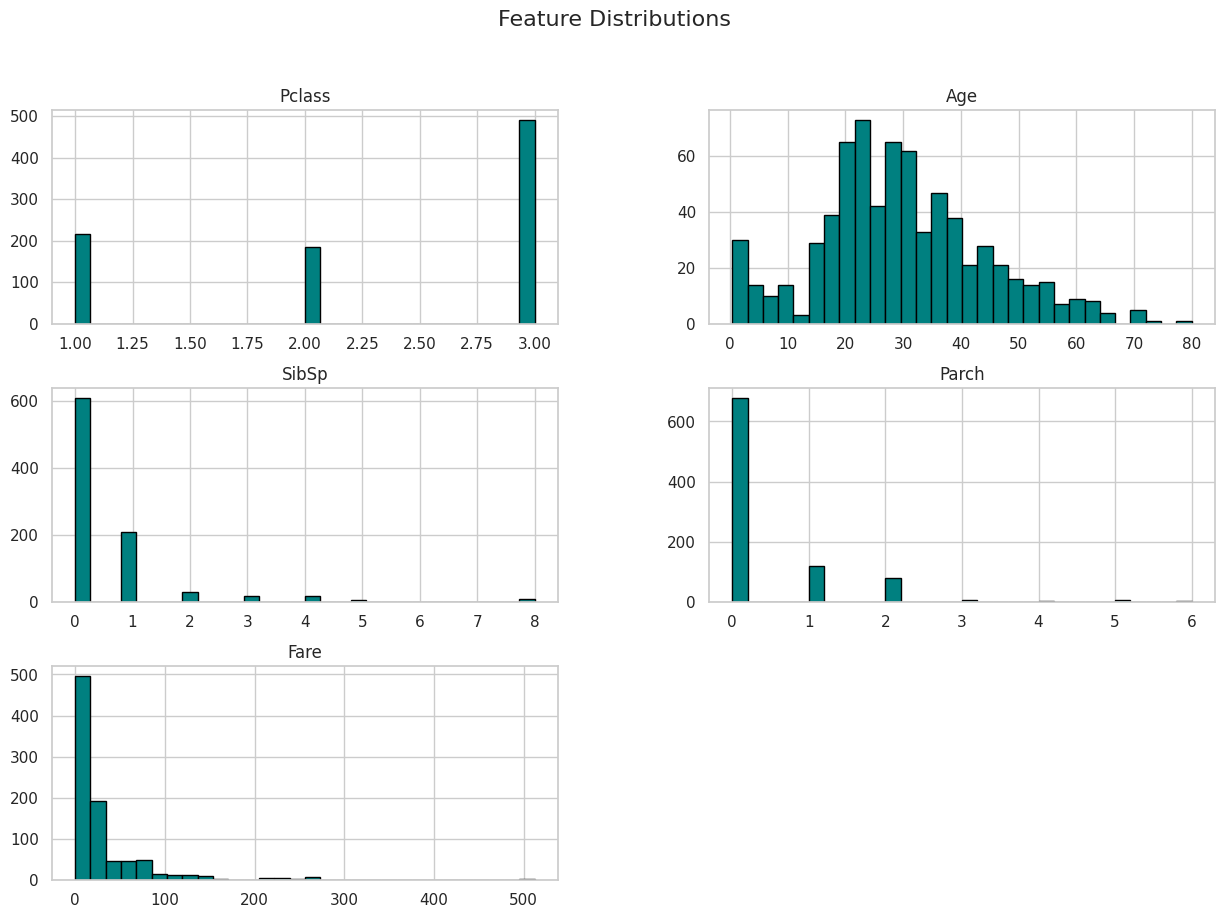

In [4]:
# Select the columns you want to plot
numeric_cols = df.select_dtypes(include=[np.number]).columns
cols_to_plot = [c for c in numeric_cols if c not in ['PassengerId', 'Survived']]

# 1. Plot Histograms using the single 'hist' command
df[cols_to_plot].hist(figsize=(15, 10), bins=30, color='teal', edgecolor='black')

# 2. Add a main title and show
plt.suptitle('Feature Distributions', fontsize=16)
plt.show()

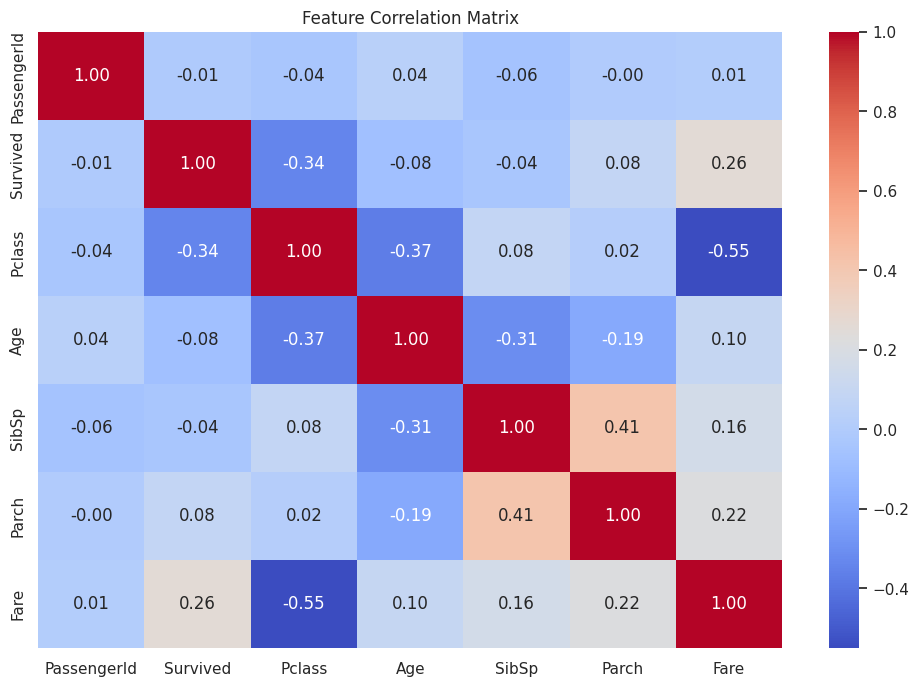

In [6]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

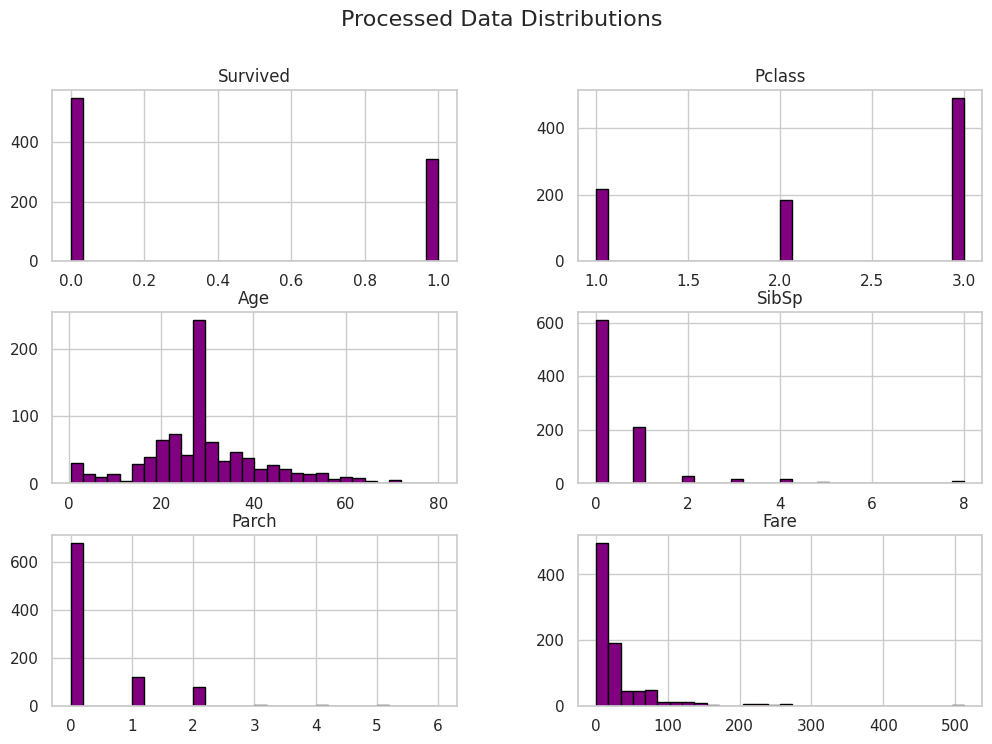

In [5]:
# 1. Identify numeric columns in the CLEAN data
# (PassengerId is already gone, so we don't need to filter it out!)
numeric_cols = bf.select_dtypes(include=[np.number]).columns

# 2. Plot Histograms
bf[numeric_cols].hist(figsize=(12, 8), bins=30, color='purple', edgecolor='black')

plt.suptitle('Processed Data Distributions', fontsize=16)
plt.show()